In [4]:
# sample_pipeline.py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from lightgbm import LGBMRegressor
import warnings
import joblib







In [5]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("--- Starting Black Friday Modeling for Notebook ---")

--- Starting Black Friday Modeling for Notebook ---


## Loading and Preprocessing Data

In [6]:
DATA_PATH ='/content/sample_data/black_friday_sales.csv'
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Place your dataset as {DATA_PATH} or change DATA_PATH variable.")
df = pd.read_csv(DATA_PATH)
print("Loaded:", df.shape)
print(df.head())



Loaded: (451748, 12)
   User_ID Product_ID Gender   Age  Occupation City_Category  \
0  1000001  P00069042      F  0-17        10.0             A   
1  1000001  P00248942      F  0-17        10.0             A   
2  1000001  P00087842      F  0-17        10.0             A   
3  1000001  P00085442      F  0-17        10.0             A   
4  1000002  P00285442      M   55+        16.0             C   

  Stay_In_Current_City_Years  Marital_Status  Product_Category_1  \
0                          2             0.0                 3.0   
1                          2             0.0                 1.0   
2                          2             0.0                12.0   
3                          2             0.0                12.0   
4                         4+             0.0                 8.0   

   Product_Category_2  Product_Category_3  Purchase  
0                 NaN                 NaN    8370.0  
1                 6.0                14.0   15200.0  
2                 NaN  

In [7]:
# drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print( df.shape)


(451748, 12)


In [8]:
# ensure id columns are strings
df["User_ID"] = df["User_ID"].astype(str)
df["Product_ID"] = df["Product_ID"].astype(str)

In [17]:
# normalize city/stay years
if "Stay_In_Current_City_Years" in df.columns:
    # Fill missing values with a placeholder before converting to int
    df["Stay_In_Current_City_Years"] = df["Stay_In_Current_City_Years"].fillna(-1)
    df["Stay_In_Current_City_Years"] = df["Stay_In_Current_City_Years"].replace({"4+": "4"})
    df["Stay_In_Current_City_Years"] = df["Stay_In_Current_City_Years"].astype(int)

In [18]:
# --------- missing indicators (before impute) ----------
prod_cat_cols = [c for c in df.columns if c.startswith("Product_Category_")]
for c in prod_cat_cols:
  new_col = c + "_was_missing"
  # only add column if it does not already exist
  if new_col not in df.columns:
     df[new_col] = df[c].isna().astype(int)

print(df.shape)
df.head()

(451748, 18)


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Product_Category_1_was_missing,Product_Category_2_was_missing,Product_Category_3_was_missing,Product_Category_1_was_missing_was_missing,Product_Category_2_was_missing_was_missing,Product_Category_3_was_missing_was_missing
0,1000001,P00069042,F,0-17,10.0,A,2,0.0,3.0,NaN,NaN,8370.0,0,1,1,0,0,0
1,1000001,P00248942,F,0-17,10.0,A,2,0.0,1.0,6.0,14.0,15200.0,0,0,0,0,0,0
2,1000001,P00087842,F,0-17,10.0,A,2,0.0,12.0,NaN,NaN,1422.0,0,1,1,0,0,0
3,1000001,P00085442,F,0-17,10.0,A,2,0.0,12.0,14.0,NaN,1057.0,0,0,1,0,0,0
4,1000002,P00285442,M,55+,16.0,C,4,0.0,8.0,NaN,NaN,7969.0,0,1,1,0,0,0


In [19]:
df.describe()


,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Product_Category_1_was_missing,Product_Category_2_was_missing,Product_Category_3_was_missing,Product_Category_1_was_missing_was_missing,Product_Category_2_was_missing_was_missing,Product_Category_3_was_missing_was_missing
count,451747.000000,451748.000000,451747.000000,451747.000000,311417.000000,138172.000000,451747.000000,451748.000000,451748.000000,451748.000000,451748.0,451748.0,451748.0
mean,8.080514,1.860307,0.409382,5.298315,9.845509,12.659222,9328.887933,0.000002,0.310640,0.694139,0.0,0.0,0.0
std,6.522867,1.290096,0.491720,3.748638,5.087433,4.125856,4978.412379,0.001488,0.462756,0.460772,0.0,0.0,0.0
min,0.000000,-1.000000,0.000000,1.000000,2.000000,3.000000,185.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
25%,2.000000,1.000000,0.000000,1.000000,5.000000,9.000000,5865.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
50%,7.000000,2.000000,0.000000,5.000000,9.000000,14.000000,8061.000000,0.000000,0.000000,1.000000,0.0,0.0,0.0
75%,14.000000,3.000000,1.000000,8.000000,15.000000,16.000000,12069.000000,0.000000,1.000000,1.000000,0.0,0.0,0.0
max,20.000000,4.000000,1.000000,18.000000,18.000000,18.000000,23961.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0


In [20]:
 print(df.nunique())

User_ID                                        5892
Product_ID                                     3601
Gender                                            2
Age                                               7
Occupation                                       21
City_Category                                     3
Stay_In_Current_City_Years                        6
Marital_Status                                    2
Product_Category_1                               18
Product_Category_2                               17
Product_Category_3                               15
Purchase                                      17634
Product_Category_1_was_missing                    2
Product_Category_2_was_missing                    2
Product_Category_3_was_missing                    2
Product_Category_1_was_missing_was_missing        1
Product_Category_2_was_missing_was_missing        1
Product_Category_3_was_missing_was_missing        1
dtype: int64


In [30]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,1
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,1
Product_Category_1,1
Product_Category_2,0


In [32]:
#dropna
df = df.dropna()
print(df.shape)
df.isnull().sum()

(451747, 18)


,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,0


## Performing Exploratory Data Analysis (EDA)

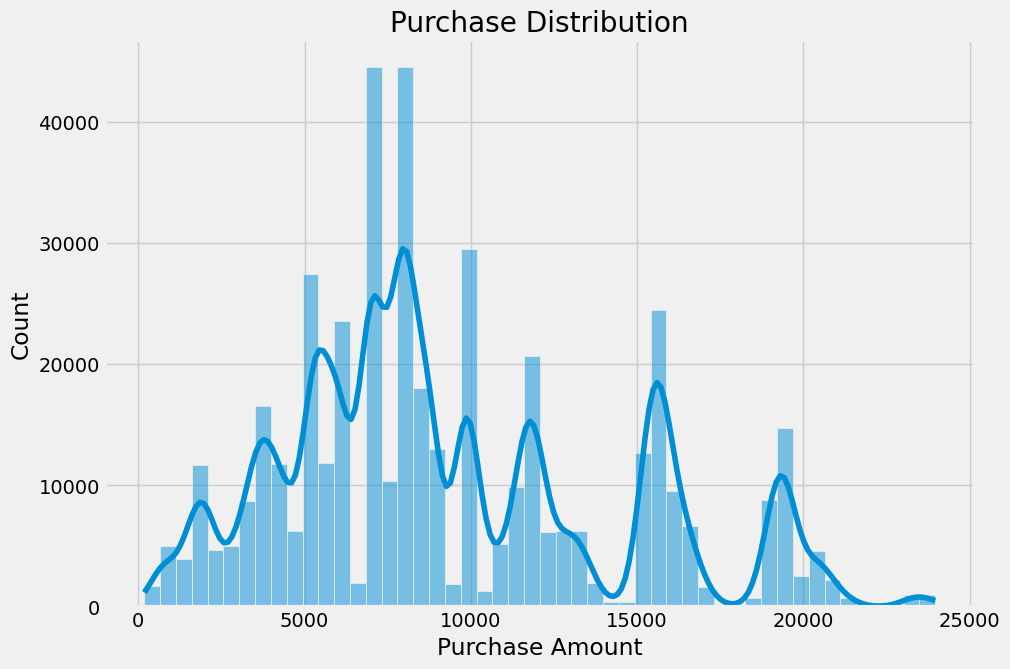

Purchase distribution plot saved to 'purchase_distribution.png'


In [33]:
    # Plot Purchase distribution
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(10, 7))
    sns.histplot(df['Purchase'], kde=True, bins=50)
    plt.title('Purchase Distribution')
    plt.xlabel('Purchase Amount')
    plt.ylabel('Count')
    plt.savefig('purchase_distribution.png')
    plt.show()
    print("Purchase distribution plot saved to 'purchase_distribution.png'")


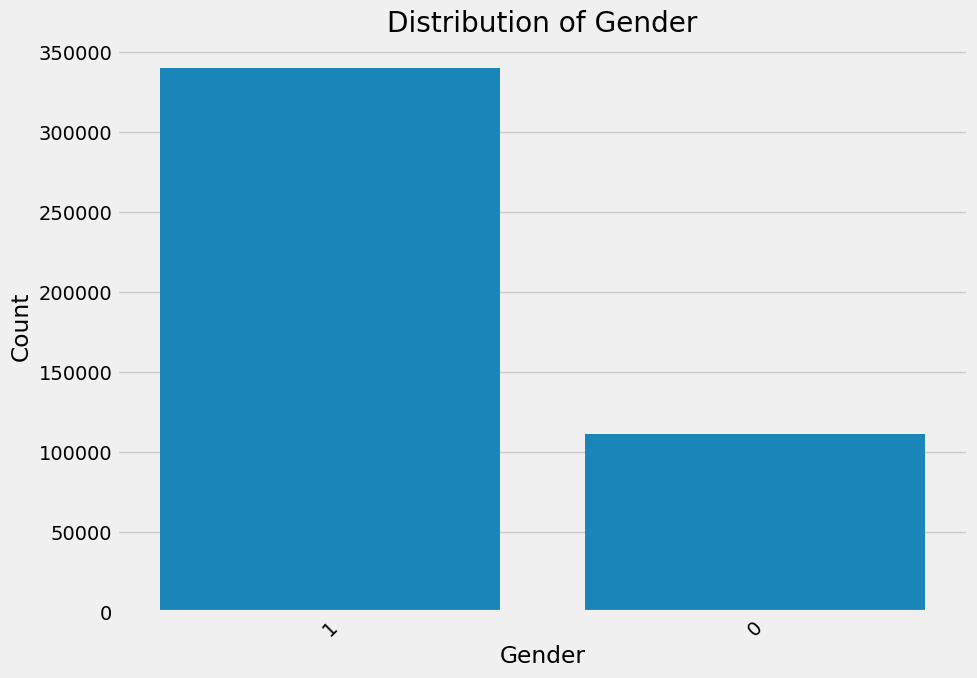

Distribution plot for Gender saved to 'gender_distribution.png'


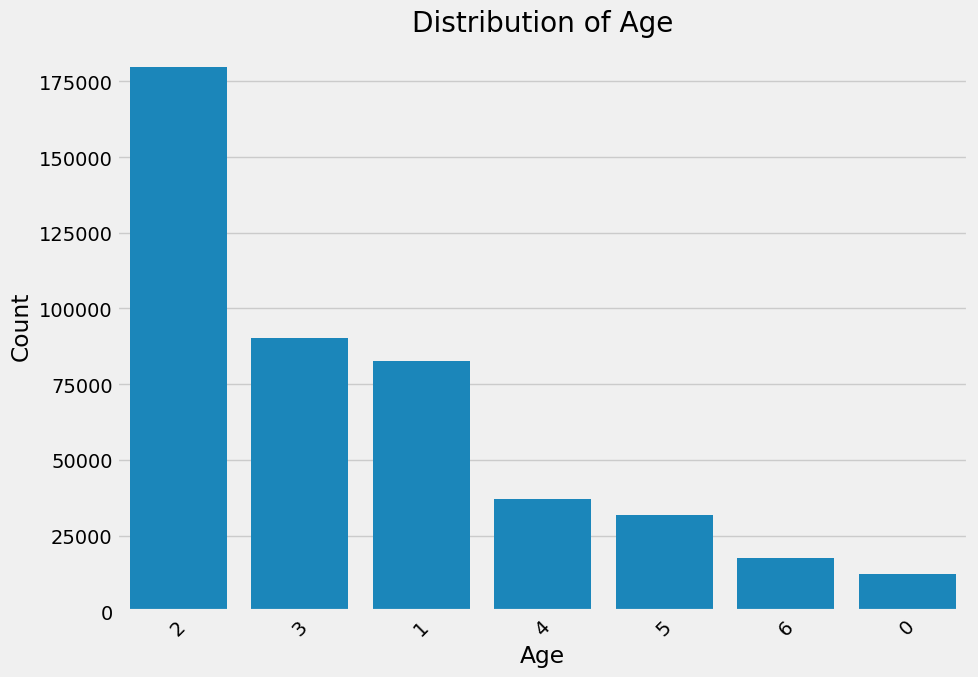

Distribution plot for Age saved to 'age_distribution.png'


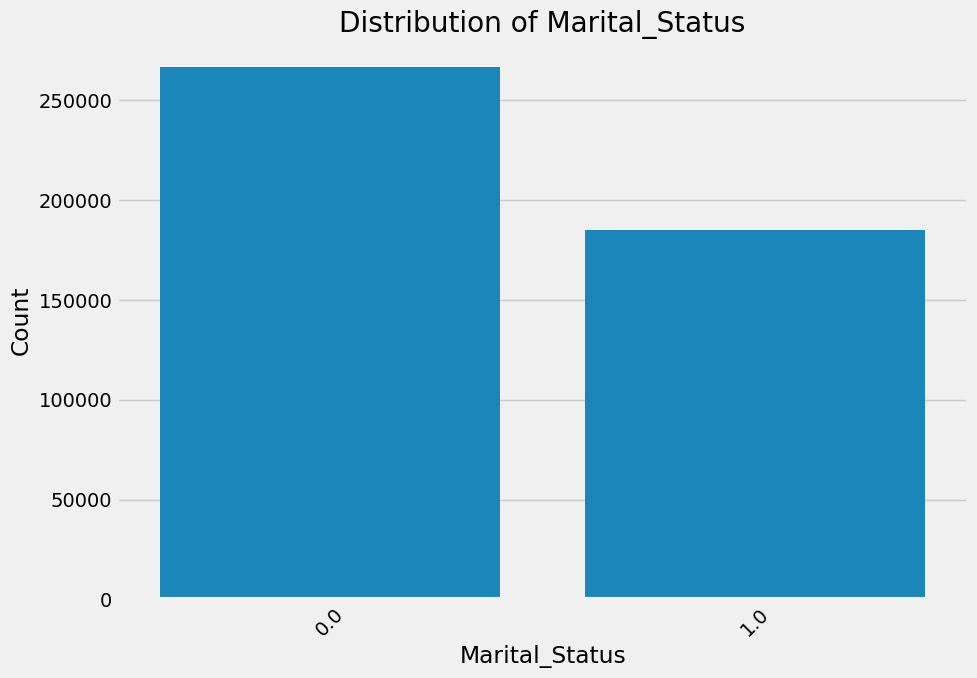

Distribution plot for Marital_Status saved to 'marital_status_distribution.png'


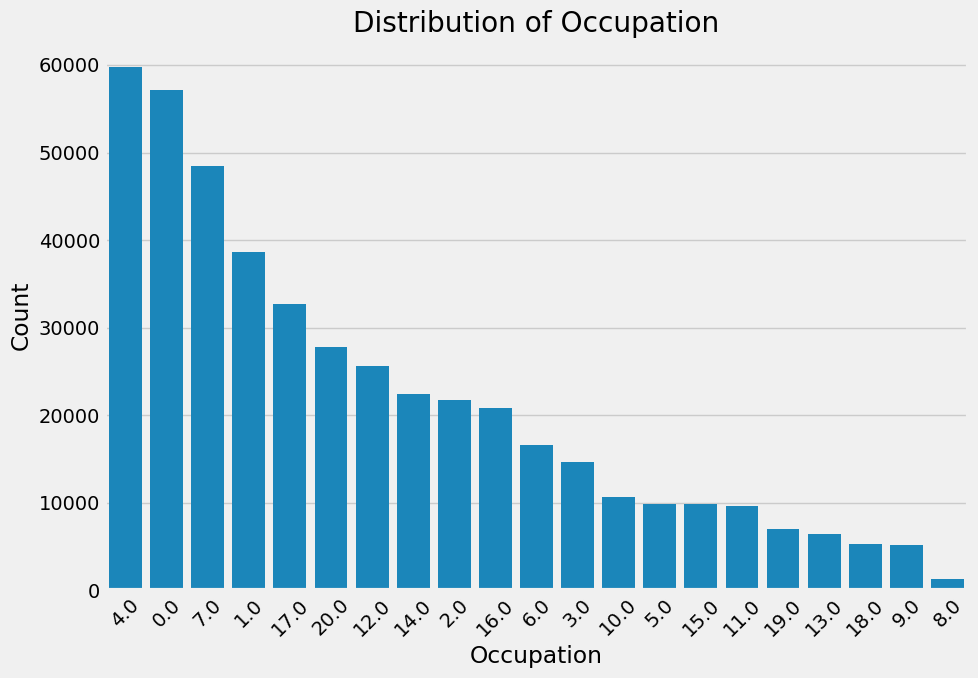

Distribution plot for Occupation saved to 'occupation_distribution.png'


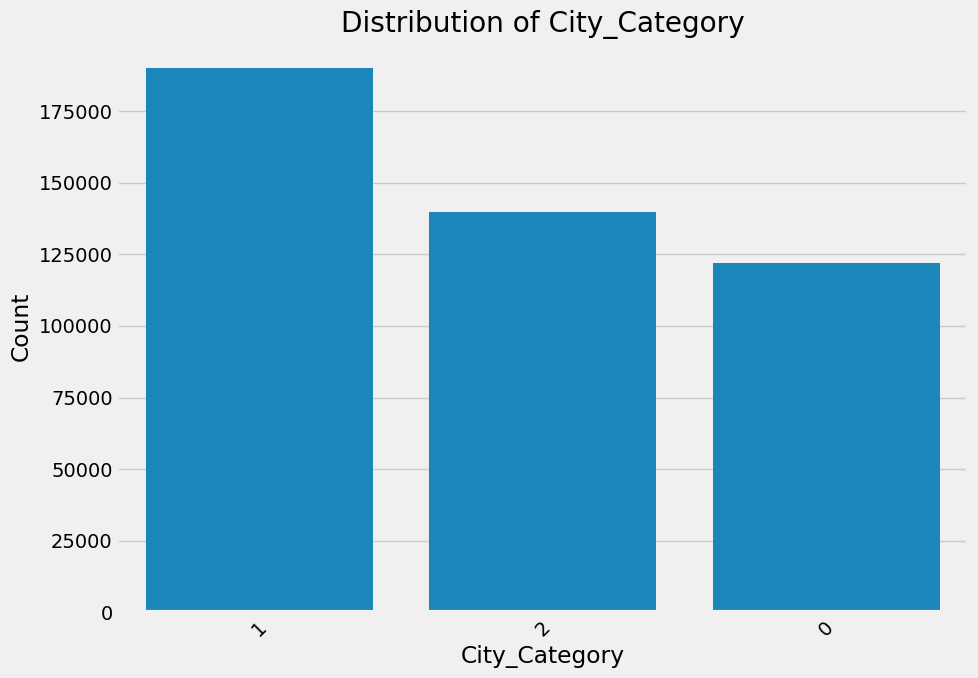

Distribution plot for City_Category saved to 'city_category_distribution.png'


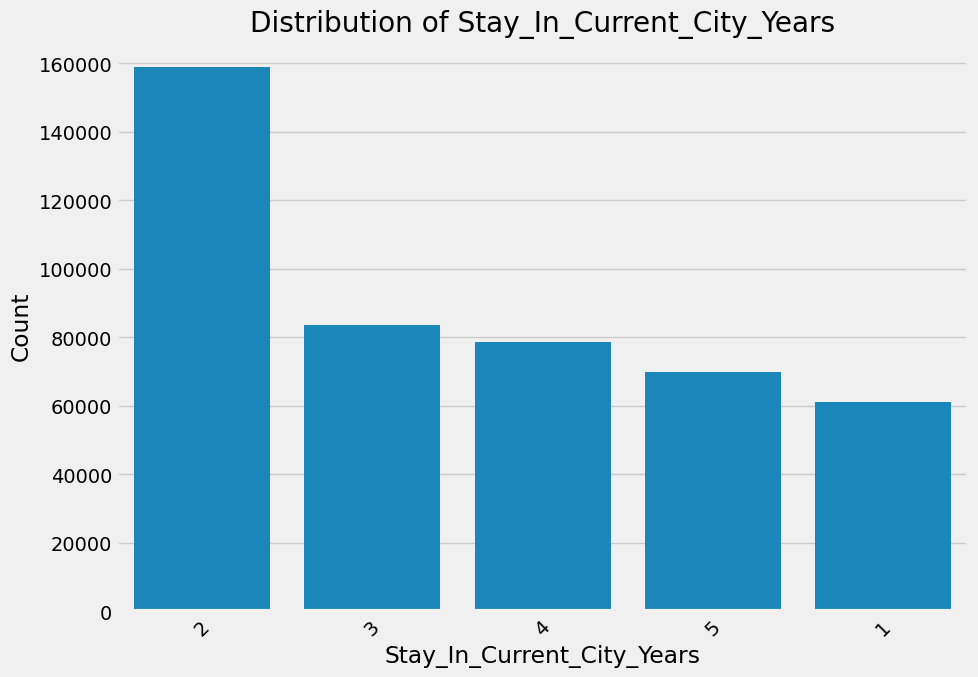

Distribution plot for Stay_In_Current_City_Years saved to 'stay_in_current_city_years_distribution.png'


In [34]:
    # Plot distribution of key categorical variables
    categorical_cols = ['Gender', 'Age', 'Marital_Status', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years']
    for col in categorical_cols:
        plt.figure(figsize=(10, 7))
        sns.countplot(x=col, data=df, order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f'{col.lower()}_distribution.png')
        plt.show()
        print(f"Distribution plot for {col} saved to '{col.lower()}_distribution.png'")


 ## Feature Engineering

In [35]:

    print("\n--- Performing Feature Engineering ---")

    # Handle missing values in Product_Category_2 and Product_Category_3
    df['Product_Category_2'].fillna(-999, inplace=True)
    df['Product_Category_3'].fillna(-999, inplace=True)
    print("Missing values in Product_Category_2 and Product_Category_3 filled with -999.")

    # Convert categorical columns to numerical using LabelEncoder
    categorical_cols_to_encode = ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']
    le = LabelEncoder()
    for col in categorical_cols_to_encode:
        df[col] = le.fit_transform(df[col])
    print("Categorical columns converted to numerical using LabelEncoder.")

    # Show the transformed data
    print("\nDataFrame Head after Feature Engineering:")
    print(df.head())


--- Performing Feature Engineering ---
Missing values in Product_Category_2 and Product_Category_3 filled with -999.
Categorical columns converted to numerical using LabelEncoder.

DataFrame Head after Feature Engineering:
   User_ID Product_ID  Gender  Age  Occupation  City_Category  \
0  1000001  P00069042       0    0        10.0              0   
1  1000001  P00248942       0    0        10.0              0   
2  1000001  P00087842       0    0        10.0              0   
3  1000001  P00085442       0    0        10.0              0   
4  1000002  P00285442       1    6        16.0              2   

   Stay_In_Current_City_Years  Marital_Status  Product_Category_1  \
0                           2             0.0                 3.0   
1                           2             0.0                 1.0   
2                           2             0.0                12.0   
3                           2             0.0                12.0   
4                           4           

## Correlation Analysis


--- Generating Correlation Matrix Heatmap ---


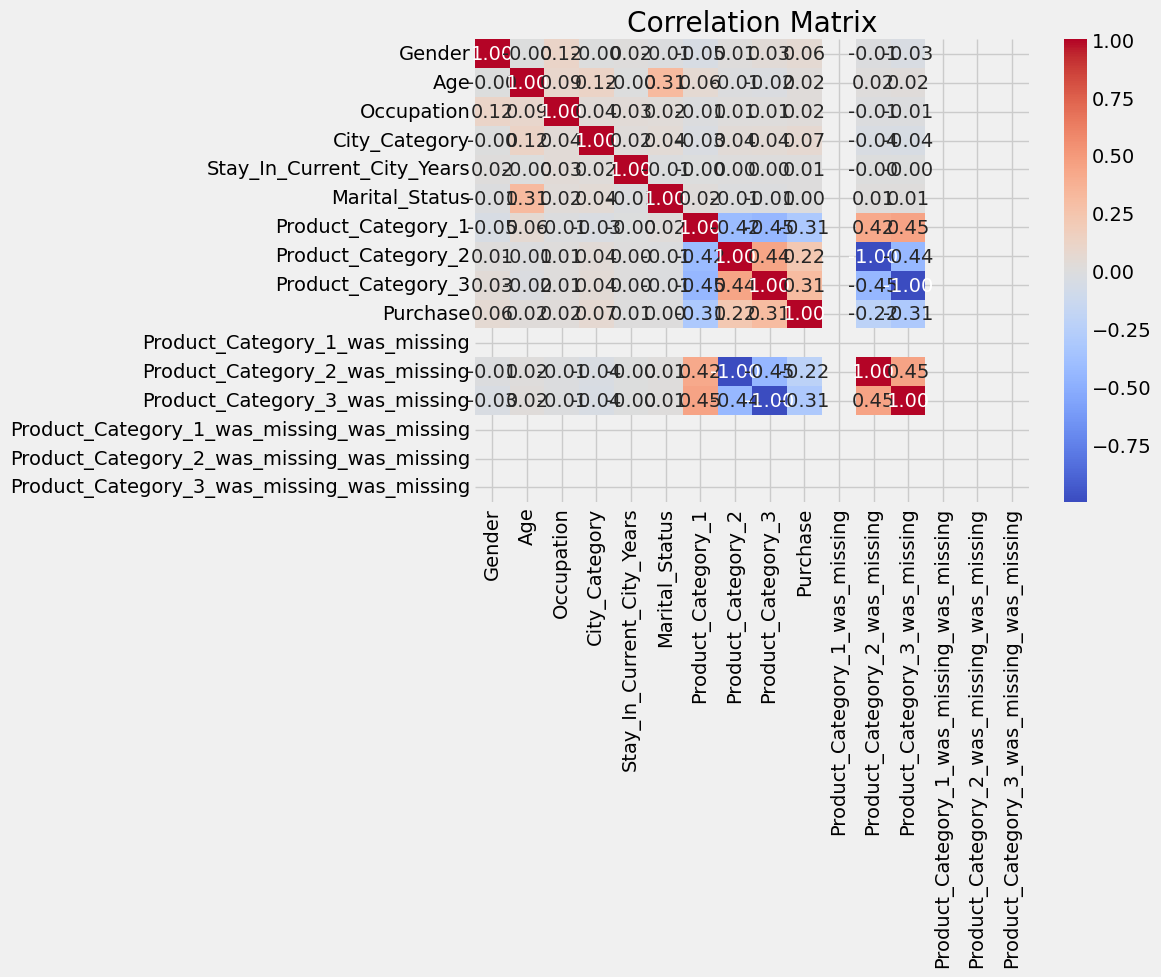

Correlation heatmap saved to 'correlation_heatmap.png'


In [36]:

    print("\n--- Generating Correlation Matrix Heatmap ---")
    plt.figure(figsize=(12, 10))
    corr = df.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png')
    plt.show()
    print("Correlation heatmap saved to 'correlation_heatmap.png'")


## Training and Evaluating Models


Training LGBM Regressor...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024490 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 99
[LightGBM] [Info] Number of data points in the train set: 338810, number of used features: 11
[LightGBM] [Info] Start training from score 9329.418267
LGBM Regressor RMSE on test set: 2907.21
LGBM Regressor Cross-Validation RMSE: 2914.80


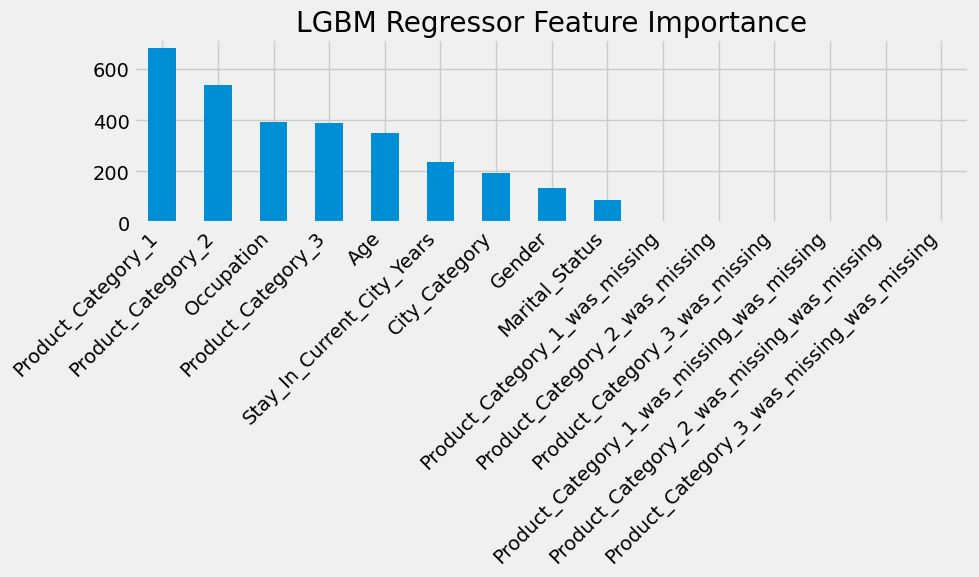


Training Random Forest Regressor...
Random Forest Regressor RMSE on test set: 3069.57
Random Forest Regressor Cross-Validation RMSE: 3071.49


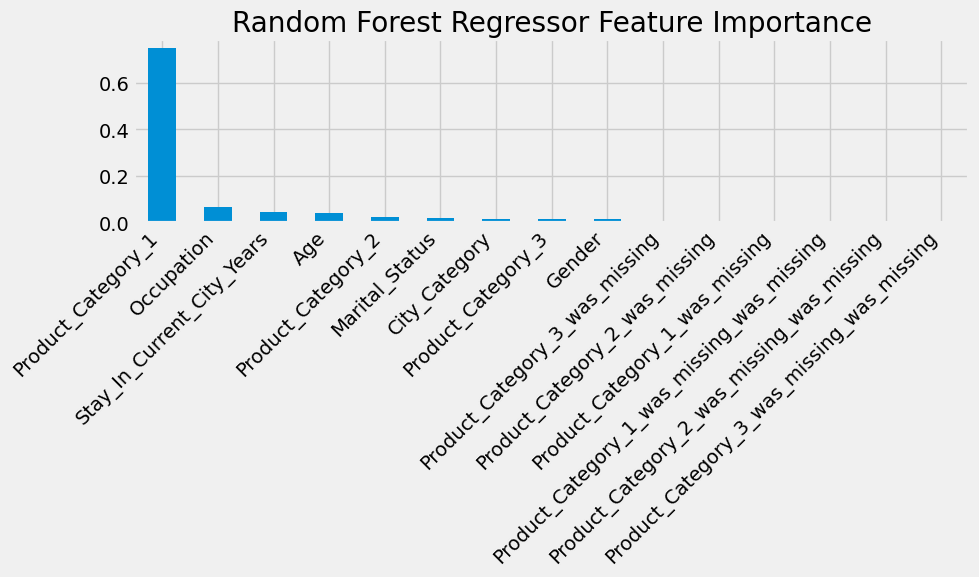


Training Extra Trees Regressor...
Extra Trees Regressor RMSE on test set: 3208.69
Extra Trees Regressor Cross-Validation RMSE: 3210.03


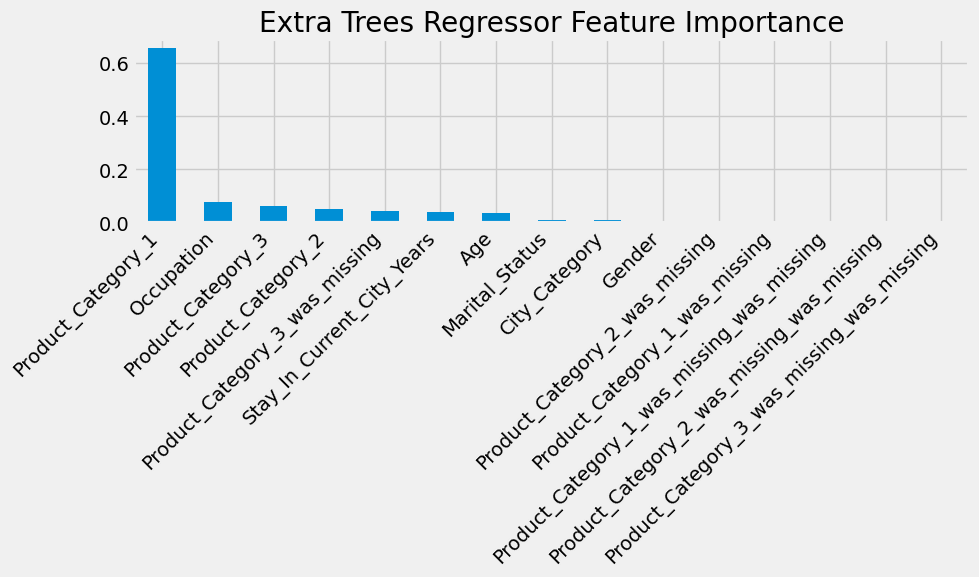

In [37]:
X = df.drop(['User_ID', 'Product_ID', 'Purchase'], axis=1)
y = df['Purchase']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

models = {
    'LGBM Regressor': LGBMRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees Regressor': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

best_model = None
best_rmse = float('inf')

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model

    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(-scores.mean())

    print(f"{name} RMSE on test set: {rmse:.2f}")
    print(f"{name} Cross-Validation RMSE: {cv_rmse:.2f}")

    feature_importances = pd.Series(model.feature_importances_, X.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    feature_importances.plot(kind='bar')
    plt.title(f'{name} Feature Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## Saving Best Model and Plotting Results

Best model (LGBMRegressor) saved to 'best_black_friday_model.joblib'


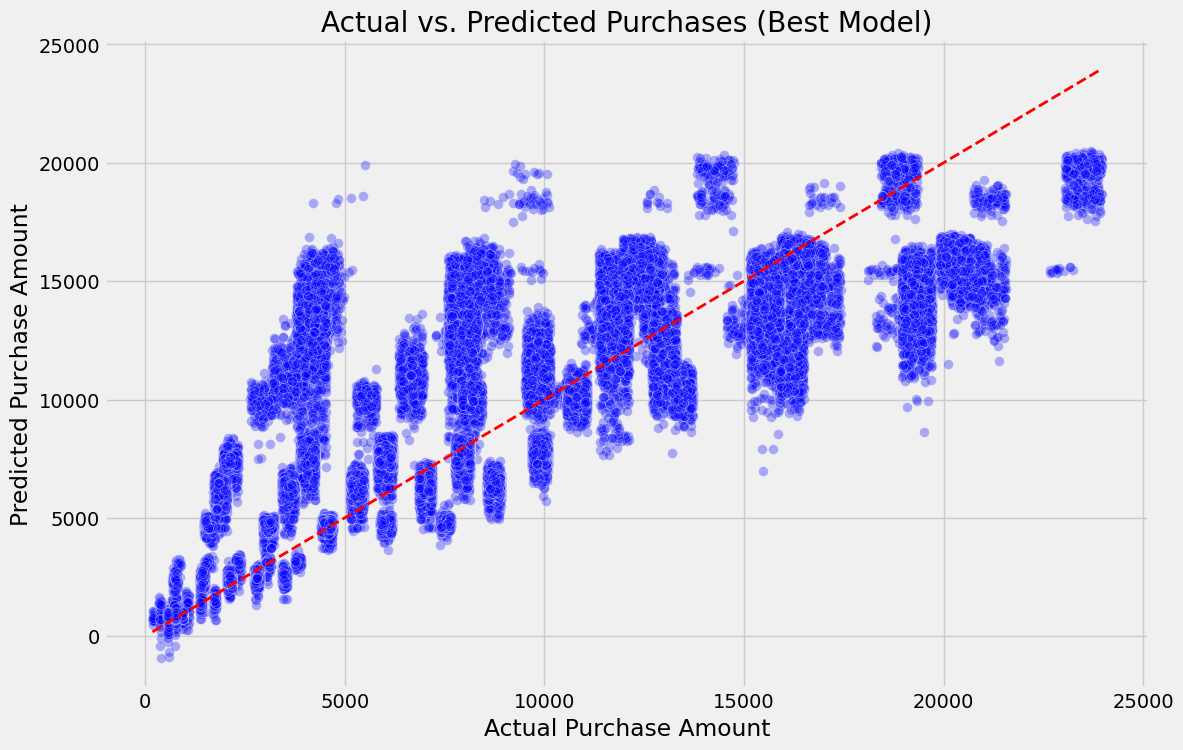


--- Analysis Pipeline Complete ---


In [38]:
if best_model:
    model_filename = 'best_black_friday_model.joblib'
    joblib.dump(best_model, model_filename)
    print(f"Best model ({best_model.__class__.__name__}) saved to '{model_filename}'")

    best_model_predictions = best_model.predict(X_test)
    plt.figure(figsize=(12, 8))
    plt.scatter(y_test, best_model_predictions, alpha=0.3, color='blue', edgecolors='w', s=50)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Purchase Amount')
    plt.ylabel('Predicted Purchase Amount')
    plt.title('Actual vs. Predicted Purchases (Best Model)')
    plt.grid(True)
    plt.show()

print("\n--- Analysis Pipeline Complete ---")